# Learning Detection Comparison (Strategies 1–3)

This notebook:
1) Runs Bayesian strategy analysis for multiple strategies (Figure 1-style)
2) Selects the dominant rule strategy automatically (go_left/go_right/go_cued)
3) Computes learning trial using:
   - Strategy 1: Sequence criterion
   - Strategy 2: Sequence + Precision
   - Strategy 3: Expert (posterior excludes chance)
4) Plots all learning trials on the rule-strategy MAP plot

In [49]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials
from scipy.stats import beta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)

# We will detect learning per RULE BLOCK, not across the entire session,
# because the task rule changes multiple times.
# Therefore "until end" means: until the end of the current block.

[standardize_dataset] Removed 11 omission trial(s) from 'Choice'.


In [50]:
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]

rule_to_strategy = {
    "go right": "go_right",
    "go to the lit arm": "go_cued",
    "go left": "go_left",
    "go to the dark arm": "go_uncued"
}



strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")

In [51]:
alpha0, beta0 = set_priors(prior_type)

Output_collection = {}
event_totals = {}

for s in strategies:
    Output_collection[s] = pd.DataFrame(columns=[
        "Alpha", "Beta",
        "MAPprobability", "Precision",
        "Alpha_interpolated", "Beta_interpolated",
        "MAPprobability_interpolated", "Precision_interpolated"
    ])
    event_totals[s] = {"success_total": 0, "failure_total": 0}

In [52]:
for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for s in strategies:

        trial_type = strategy_functions[s](rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[s]["success_total"],
            event_totals[s]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[s]["success_total"] = success_total
        event_totals[s]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[s].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[s]

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[s] = pd.concat(
            [Output_collection[s], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

In [53]:
# Session-end lookup: for each trial, find the last trial index of its session
session_last = TestData.groupby("SessionIndex").apply(lambda g: g.index[-1], include_groups=False)
TestData["session_end_idx"] = TestData["SessionIndex"].map(session_last)
session_end_array = TestData["session_end_idx"].values

print("Session end indices:")
for sid in sorted(TestData["SessionIndex"].unique()):
    end_idx = int(TestData[TestData["SessionIndex"] == sid].index[-1])
    rule = TestData[TestData["SessionIndex"] == sid]["TargetRule"].iloc[0]
    print(f"  Session {sid}: ends at trial index {end_idx}  (rule: {rule})")

Session end indices:
  Session 1: ends at trial index 106  (rule: go right)
  Session 2: ends at trial index 203  (rule: go right)
  Session 3: ends at trial index 309  (rule: go right)
  Session 4: ends at trial index 407  (rule: go left)
  Session 5: ends at trial index 470  (rule: go left)
  Session 6: ends at trial index 570  (rule: go right)
  Session 7: ends at trial index 676  (rule: go right)
  Session 8: ends at trial index 776  (rule: go left)
  Session 9: ends at trial index 881  (rule: go left)
  Session 10: ends at trial index 981  (rule: go right)
  Session 11: ends at trial index 1033  (rule: go right)
  Session 12: ends at trial index 1132  (rule: go left)
  Session 13: ends at trial index 1207  (rule: go left)
  Session 14: ends at trial index 1307  (rule: go right)
  Session 15: ends at trial index 1348  (rule: go right)
  Session 16: ends at trial index 1448  (rule: go left)
  Session 17: ends at trial index 1489  (rule: go left)
  Session 18: ends at trial index 158

In [54]:
# --- Get block boundaries (rule changes) ---
if "RuleChangeTrials" in TestData.columns:
    # e.g. per-trial vector; unique trial indices where rule changes
    block_boundaries = list(
        TestData.index[TestData["RuleChangeTrials"] == 1])
elif "NewSessionTrials" in TestData.columns:
    block_boundaries = sorted(set(TestData["NewSessionTrials"].dropna().astype(int).tolist()))
else:
    block_boundaries = []

# Remove 0 and out-of-range values if they exist
block_boundaries = [b for b in block_boundaries if 0 < b < len(TestData)]

In [55]:
# ------------------------------------------------
# Detect rule blocks and their target strategies
# ------------------------------------------------

block_starts = [0] + block_boundaries
block_ends = block_boundaries + [len(TestData)]

# Try to read rule labels from dataset
if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    # fallback labels
    block_labels = [
        "go right",
        "go to the lit arm",
        "go left",
        "go to the dark arm"
    ][:len(block_starts)]

print("Block labels:", block_labels)

# Map rule → strategy

block_target_strategies = [
    rule_to_strategy[label] for label in block_labels
]

print("Block target strategies:", block_target_strategies)

Block labels: ['go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right']
Block target strategies: ['go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right']


In [56]:
print("block boundaries:", block_boundaries)
print("block starts:", block_starts)
print("block ends:", block_ends)

block boundaries: [224, 428, 591, 797, 1002, 1153, 1328, 1469, 1609, 1744]
block starts: [0, 224, 428, 591, 797, 1002, 1153, 1328, 1469, 1609, 1744]
block ends: [224, 428, 591, 797, 1002, 1153, 1328, 1469, 1609, 1744, 1857]


In [57]:
def learning_trial_sequence_per_block(MAP,
                                      block_boundaries,
                                      chance=0.5,
                                      min_trials=5):
    """
    Sequence criterion per block:
    For each rule block, find first trial t such that
    MAP[t:block_end] > chance for all remaining trials,
    with at least min_trials remaining.
    min_trials guards against spurious detections caused by a
    small number of trials at a session boundary happening to
    exceed chance.
    """

    MAP = np.asarray(MAP)
    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP[t:end]
            if len(remaining) >= min_trials and np.all(remaining > chance):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [58]:
def learning_trial_sequence_precision_per_block(Output_collection,
                                                target,
                                                others,
                                                block_boundaries,
                                                chance=0.5,
                                                min_trials=5):
    """
    Strategy 2 per block:
    - MAP(target) stays > chance until block end, with at least min_trials remaining
    - AND Precision(target) at learning trial >= max Precision(others)
    """

    MAP_t  = Output_collection[target]["MAPprobability"].values
    PREC_t = Output_collection[target]["Precision"].values

    PREC_others = np.vstack([
        Output_collection[o]["Precision"].values for o in others
    ])

    max_other = PREC_others.max(axis=0)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP_t)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP_t[t:]
            if (len(remaining) >= min_trials and
                np.all(remaining > chance) and
                PREC_t[t] >= max_other[t]):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [59]:
from scipy.stats import beta

def learning_trial_expert_per_block(Output_collection,
                                    target,
                                    block_boundaries,
                                    chance=0.5,
                                    prob_thresh=0.95):
    """
    Strategy 3 per block:
    P(p > chance) >= prob_thresh for all trials t:block_end
    """

    A = Output_collection[target]["Alpha"].values
    B = Output_collection[target]["Beta"].values

    p_gt = 1.0 - beta.cdf(chance, A, B)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(p_gt)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            if np.all(p_gt[t:] >= prob_thresh):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [60]:
if "RuleChangeTrials" in TestData.columns:
    block_boundaries = sorted(
        set(TestData["RuleChangeTrials"].dropna().astype(int))
    )
else:
    block_boundaries = []

In [61]:
t1_list = []
t2_list = []
t3_list = []

min_trials = 5  # minimum remaining trials required to declare learning

for start, end, strategy in zip(block_starts, block_ends, block_target_strategies):

    MAP = Output_collection[strategy]["MAPprobability"].values

    # Strategy 1: Sequence criterion (MAP > 0.5 until end of session)
    lt1 = None
    for t in range(start, end):
        sess_end = int(session_end_array[t]) + 1
        remaining = MAP[t:sess_end]
        if len(remaining) >= min_trials and np.all(remaining > 0.5):
            lt1 = t
            break
    t1_list.append(lt1)

    # Strategy 2: Sequence + Precision (MAP > 0.5 until session end AND precision dominates)
    PREC = Output_collection[strategy]["Precision"].values

    others = [s for s in rule_strategies if s != strategy]

    PREC_others = np.vstack([
        Output_collection[o]["Precision"].values
        for o in others
    ]).astype(float)

    max_other = PREC_others.max(axis=0)

    lt2 = None
    for t in range(start, end):
        sess_end = int(session_end_array[t]) + 1
        remaining = MAP[t:sess_end]
        if (len(remaining) >= min_trials and
            np.all(remaining > 0.5) and
            PREC[t] >= max_other[t]):
            lt2 = t
            break
    t2_list.append(lt2)

    # Strategy 3: Expert criterion (P(p > 0.5) >= 0.95 until session end)
    A = Output_collection[strategy]["Alpha"].values.astype(float)
    B = Output_collection[strategy]["Beta"].values.astype(float)

    p_gt = 1 - beta.cdf(0.5, A, B)

    lt3 = None
    for t in range(start, end):
        sess_end = int(session_end_array[t]) + 1
        if np.all(p_gt[t:sess_end] >= 0.95):
            lt3 = t
            break
    t3_list.append(lt3)

In [62]:
print("S1:", t1_list)
print("S2:", t2_list)
print("S3:", t3_list)

S1: [28, 300, 465, 620, 862, 1025, 1176, 1349, 1485, 1624, 1752]
S2: [36, 302, 493, 622, 863, 1026, 1178, 1349, 1490, 1624, 1752]
S3: [97, 307, 533, 672, 877, 1032, 1198, 1416, 1500, 1668, 1784]


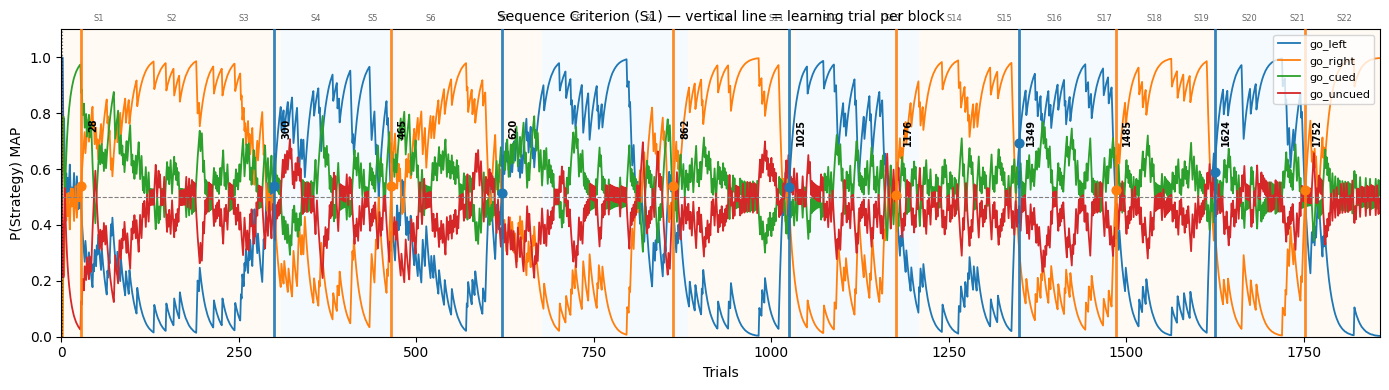

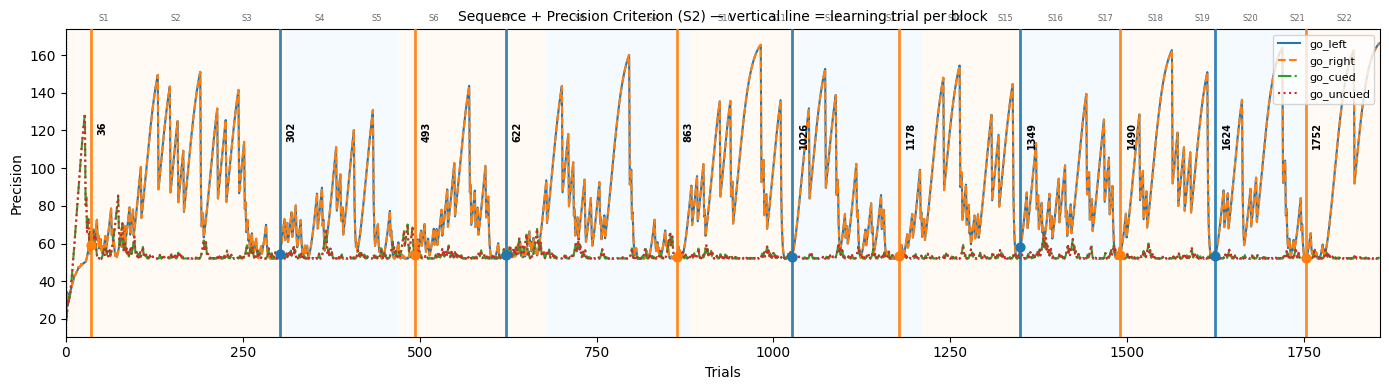

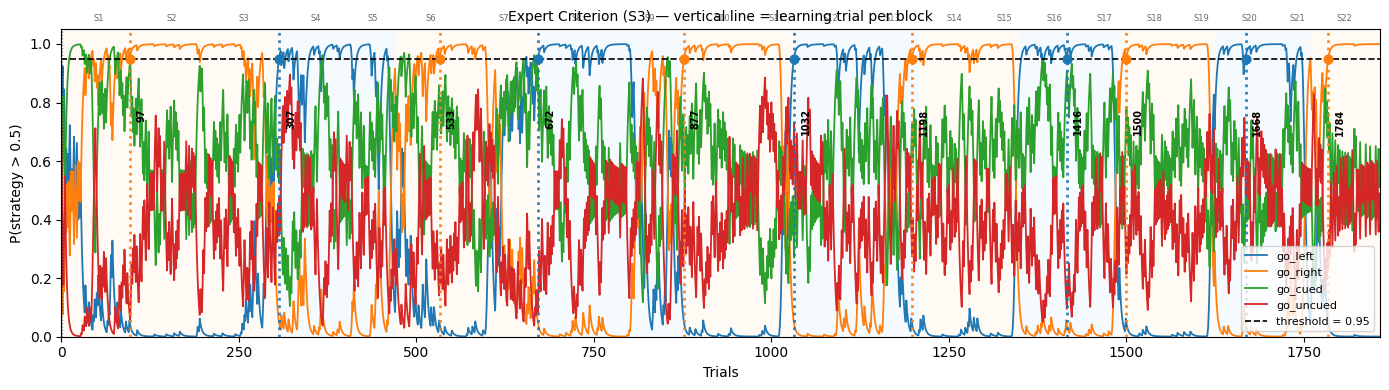

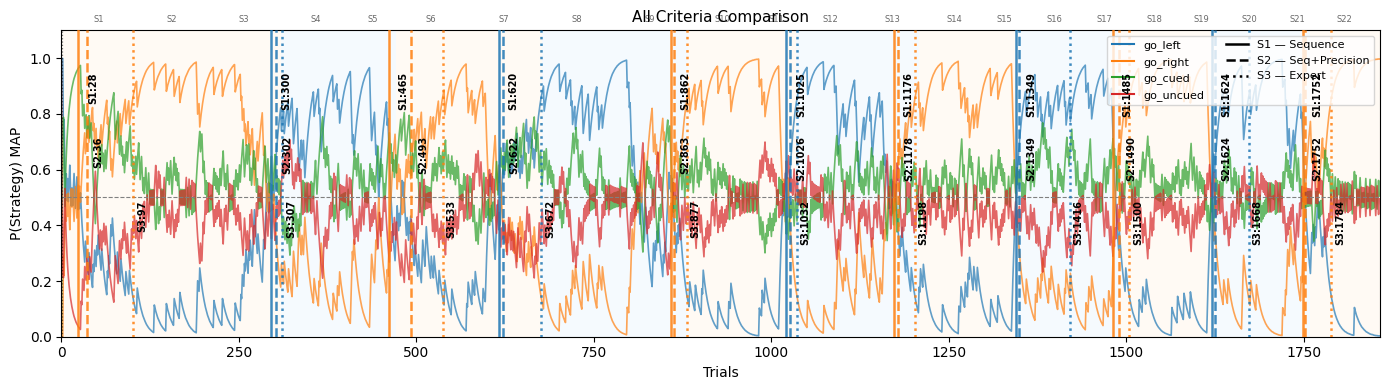

In [63]:
from matplotlib.lines import Line2D
from scipy.stats import beta as beta_dist

color_map = {
    "go_left":   "#1f77b4",
    "go_right":  "#ff7f0e",
    "go_cued":   "#2ca02c",
    "go_uncued": "#d62728",
}

rule_bg = {
    "go right":           "#fff3e0",
    "go left":            "#e3f2fd",
    "go to the lit arm":  "#e8f5e9",
    "go to the dark arm": "#fce4ec",
}

all_rule_strategies = ["go_left", "go_right", "go_cued", "go_uncued"]

# Build session spans for background shading
session_spans = []
for sid in sorted(TestData["SessionIndex"].unique()):
    s = TestData[TestData["SessionIndex"] == sid]
    session_spans.append((s.index[0], s.index[-1], int(sid), s["TargetRule"].iloc[0]))

def shade_sessions(ax, session_spans, label_on_top=False):
    for start_idx, end_idx, sid, rule in session_spans:
        bg = rule_bg.get(rule, "#f5f5f5")
        ax.axvspan(start_idx, end_idx + 1, facecolor=bg, alpha=0.35, zorder=0)
        if label_on_top:
            mid = (start_idx + end_idx) / 2
            ax.text(mid, 1.02, f"S{sid}", fontsize=6, color="dimgrey",
                    ha="center", va="bottom", transform=ax.get_xaxis_transform())

def draw_block_lines(ax, boundaries):
    for b in boundaries:
        ax.axvline(b, color="black", linewidth=0.9, linestyle=":", alpha=0.5, zorder=3)

def add_learning_labels(ax, lt_list, strategies, y=0.78, prefix=""):
    for lt, strat in zip(lt_list, strategies):
        if lt is not None:
            label = f"{prefix}{lt}" if prefix else str(lt)
            ax.text(lt + no_Trials * 0.005, y, label,
                    fontsize=7, color="black", fontweight="bold",
                    va="top", rotation=90, zorder=6)

# -------------------------------------------------------
# Figure 1: MAP curves + S1 Sequence Criterion markers
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(14, 4))

shade_sessions(ax1, session_spans, label_on_top=True)
draw_block_lines(ax1, block_boundaries)

for s in all_rule_strategies:
    ax1.plot(Output_collection[s]["MAPprobability"],
             linewidth=1.3, color=color_map[s], label=s, zorder=2)

ax1.axhline(0.5, linestyle="--", linewidth=0.8, color="gray", zorder=2)

for lt, strat in zip(t1_list, block_target_strategies):
    if lt is not None:
        ax1.axvline(lt, color=color_map[strat], linewidth=2, alpha=0.9, zorder=4)
        ax1.scatter(lt, Output_collection[strat]["MAPprobability"].values[lt],
                    s=40, color=color_map[strat], zorder=5)

add_learning_labels(ax1, t1_list, block_target_strategies, y=0.78)

ax1.set_xlim(0, no_Trials)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel("P(Strategy) MAP")
ax1.set_xlabel("Trials")
ax1.set_title("Sequence Criterion (S1) — vertical line = learning trial per block", fontsize=10)
ax1.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Figure 2: Precision + S2 markers
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 4))

shade_sessions(ax2, session_spans, label_on_top=True)
draw_block_lines(ax2, block_boundaries)

styles = {
    "go_left":   "-",
    "go_right":  "--",
    "go_cued":   "-.",
    "go_uncued": ":",
}
for s in all_rule_strategies:
    ax2.plot(Output_collection[s]["Precision"],
             linewidth=1.5, linestyle=styles[s],
             color=color_map[s], label=s, zorder=2)

for lt, strat in zip(t2_list, block_target_strategies):
    if lt is not None:
        ax2.axvline(lt, color=color_map[strat], linewidth=2, alpha=0.9, zorder=4)
        ax2.scatter(lt, Output_collection[strat]["Precision"].values[lt],
                    s=40, color=color_map[strat], zorder=5)

prec_max = max(Output_collection[s]["Precision"].max() for s in all_rule_strategies)
add_learning_labels(ax2, t2_list, block_target_strategies, y=prec_max * 0.75)

ax2.set_xlim(0, no_Trials)
ax2.set_ylabel("Precision")
ax2.set_xlabel("Trials")
ax2.set_title("Sequence + Precision Criterion (S2) — vertical line = learning trial per block", fontsize=10)
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Figure 3: P(strategy > 0.5) + S3 markers
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(14, 4))

shade_sessions(ax3, session_spans, label_on_top=True)
draw_block_lines(ax3, block_boundaries)

for s in all_rule_strategies:
    A = Output_collection[s]["Alpha_interpolated"].values.astype(float)
    B = Output_collection[s]["Beta_interpolated"].values.astype(float)
    p_gt = 1.0 - beta_dist.cdf(0.5, A, B)
    ax3.plot(p_gt, color=color_map[s], linewidth=1.3, label=s, zorder=2)

ax3.axhline(0.95, color="black", linestyle="--", linewidth=1.2, label="threshold = 0.95", zorder=2)

for lt, strat in zip(t3_list, block_target_strategies):
    if lt is not None:
        ax3.axvline(lt, color=color_map[strat], linewidth=2, linestyle=":", alpha=0.9, zorder=4)
        ax3.scatter(lt, 0.95, s=40, color=color_map[strat], zorder=5)

add_learning_labels(ax3, t3_list, block_target_strategies, y=0.78)

ax3.set_xlim(0, no_Trials)
ax3.set_ylim(0, 1.05)
ax3.set_ylabel("P(strategy > 0.5)")
ax3.set_xlabel("Trials")
ax3.set_title("Expert Criterion (S3) — vertical line = learning trial per block", fontsize=10)
ax3.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# Figure 4: All 3 criteria overlaid (comparison)
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(14, 4))

shade_sessions(ax4, session_spans, label_on_top=True)
draw_block_lines(ax4, block_boundaries)

for s in all_rule_strategies:
    ax4.plot(Output_collection[s]["MAPprobability"],
             linewidth=1.2, color=color_map[s], label=s, alpha=0.7, zorder=2)

ax4.axhline(0.5, linestyle="--", linewidth=0.8, color="gray", zorder=2)

offset = 4
for lt, strat in zip(t1_list, block_target_strategies):
    if lt is not None:
        ax4.axvline(lt - offset, color=color_map[strat], linewidth=1.8, linestyle="-",  alpha=0.85, zorder=4)
for lt, strat in zip(t2_list, block_target_strategies):
    if lt is not None:
        ax4.axvline(lt,          color=color_map[strat], linewidth=1.8, linestyle="--", alpha=0.85, zorder=4)
for lt, strat in zip(t3_list, block_target_strategies):
    if lt is not None:
        ax4.axvline(lt + offset, color=color_map[strat], linewidth=1.8, linestyle=":",  alpha=0.85, zorder=4)

add_learning_labels(ax4, t1_list, block_target_strategies, y=0.95, prefix="S1:")
add_learning_labels(ax4, t2_list, block_target_strategies, y=0.72, prefix="S2:")
add_learning_labels(ax4, t3_list, block_target_strategies, y=0.49, prefix="S3:")

ax4.set_xlim(0, no_Trials)
ax4.set_ylim(0, 1.1)
ax4.set_ylabel("P(Strategy) MAP")
ax4.set_xlabel("Trials")
ax4.set_title("All Criteria Comparison", fontsize=11)

strat_lines = [Line2D([0],[0], color=color_map[s], lw=1.5, label=s) for s in all_rule_strategies]
crit_lines  = [
    Line2D([0],[0], color="black", lw=1.8, linestyle="-",  label="S1 — Sequence"),
    Line2D([0],[0], color="black", lw=1.8, linestyle="--", label="S2 — Seq+Precision"),
    Line2D([0],[0], color="black", lw=1.8, linestyle=":",  label="S3 — Expert"),
]
ax4.legend(handles=strat_lines + crit_lines, loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [64]:
# -------------------------------------------------------
# Results Table + Summary
# -------------------------------------------------------
df_results = pd.DataFrame({
    "Block": block_labels,
    "Target Strategy": block_target_strategies,
    "S1 — Sequence": t1_list,
    "S2 — Seq+Precision": t2_list,
    "S3 — Expert": t3_list
})

df_display = df_results.copy()
for col in ["S1 — Sequence", "S2 — Seq+Precision", "S3 — Expert"]:
   df_display[col] = df_display[col].apply(
    lambda x: f"Trial {int(x)}" if pd.notna(x) else "Not learned"
  ) 


display(df_display)

print("\n=== Learning Detection Summary ===")
for i, row in df_results.iterrows():
    s1 = f"trial {int(row['S1 — Sequence'])}" if pd.notna(row["S1 — Sequence"]) else "not detected"
    s2 = f"trial {int(row['S2 — Seq+Precision'])}" if pd.notna(row["S2 — Seq+Precision"]) else "not detected"
    s3 = f"trial {int(row['S3 — Expert'])}" if pd.notna(row["S3 — Expert"]) else "not detected"

    print(f"  S1 (Sequence):       {s1}")
    print(f"  S2 (Seq+Precision):  {s2}")
    print(f"  S3 (Expert):         {s3}")

print("\nNote: S3 >= S2 >= S1 — each criterion is stricter than the previous,")
print("so learning is detected later (or not at all) as the criterion gets more conservative.")


,Block,Target Strategy,S1 — Sequence,S2 — Seq+Precision,S3 — Expert
0,go right,go_right,Trial 28,Trial 36,Trial 97
1,go left,go_left,Trial 300,Trial 302,Trial 307
2,go right,go_right,Trial 465,Trial 493,Trial 533
3,go left,go_left,Trial 620,Trial 622,Trial 672
4,go right,go_right,Trial 862,Trial 863,Trial 877
5,go left,go_left,Trial 1025,Trial 1026,Trial 1032
6,go right,go_right,Trial 1176,Trial 1178,Trial 1198
7,go left,go_left,Trial 1349,Trial 1349,Trial 1416
8,go right,go_right,Trial 1485,Trial 1490,Trial 1500
9,go left,go_left,Trial 1624,Trial 1624,Trial 1668



=== Learning Detection Summary ===
  S1 (Sequence):       trial 28
  S2 (Seq+Precision):  trial 36
  S3 (Expert):         trial 97
  S1 (Sequence):       trial 300
  S2 (Seq+Precision):  trial 302
  S3 (Expert):         trial 307
  S1 (Sequence):       trial 465
  S2 (Seq+Precision):  trial 493
  S3 (Expert):         trial 533
  S1 (Sequence):       trial 620
  S2 (Seq+Precision):  trial 622
  S3 (Expert):         trial 672
  S1 (Sequence):       trial 862
  S2 (Seq+Precision):  trial 863
  S3 (Expert):         trial 877
  S1 (Sequence):       trial 1025
  S2 (Seq+Precision):  trial 1026
  S3 (Expert):         trial 1032
  S1 (Sequence):       trial 1176
  S2 (Seq+Precision):  trial 1178
  S3 (Expert):         trial 1198
  S1 (Sequence):       trial 1349
  S2 (Seq+Precision):  trial 1349
  S3 (Expert):         trial 1416
  S1 (Sequence):       trial 1485
  S2 (Seq+Precision):  trial 1490
  S3 (Expert):         trial 1500
  S1 (Sequence):       trial 1624
  S2 (Seq+Precision):  trial 1